In [1]:
from sklearn.datasets import fetch_openml
x,y = fetch_openml("mnist_784",version=1,return_X_y=True,as_frame=False)

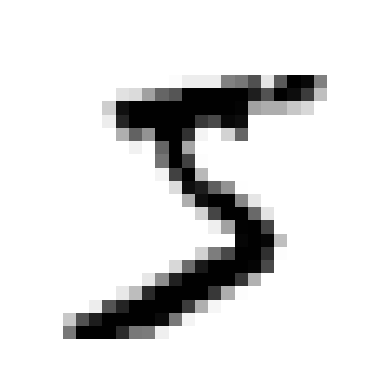

In [2]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np

some_digit = x[0]
some_digit_image = some_digit.reshape(28,28)
plt.imshow(some_digit_image,cmap="binary")
plt.axis("off")
plt.show()

In [3]:
y = y.astype(np.uint8)

In [4]:
X_train, X_test, y_train, y_test = x[:60000], x[60000:], y[:60000], y[60000:]

In [5]:
y_train_5 = (y_train == 5)
y_test_5 = (y_test == 5)

In [6]:
from sklearn.linear_model import SGDClassifier
sgd_clf = SGDClassifier(random_state=42)
sgd_clf.fit(X_train,y_train_5)

,"loss loss: {'hinge', 'log_loss', 'modified_huber', 'squared_hinge', 'perceptron', 'squared_error', 'huber', 'epsilon_insensitive', 'squared_epsilon_insensitive'}, default='hinge'The loss function to be used.- 'hinge' gives a linear SVM.- 'log_loss' gives logistic regression, a probabilistic classifier.- 'modified_huber' is another smooth loss that brings tolerance to outliers as well as probability estimates.- 'squared_hinge' is like hinge but is quadratically penalized.- 'perceptron' is the linear loss used by the perceptron algorithm.- The other losses, 'squared_error', 'huber', 'epsilon_insensitive' and 'squared_epsilon_insensitive' are designed for regression but can be useful in classification as well; see :class:`~sklearn.linear_model.SGDRegressor` for a description.More details about the losses formulas can be found in the :ref:`User Guide` and you can find a visualisation of the lossfunctions in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_loss_functions.py`.",'hinge'
,"penalty penalty: {'l2', 'l1', 'elasticnet', None}, default='l2'The penalty (aka regularization term) to be used. Defaults to 'l2'which is the standard regularizer for linear SVM models. 'l1' and'elasticnet' might bring sparsity to the model (feature selection)not achievable with 'l2'. No penalty is added when set to `None`.You can see a visualisation of the penalties in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_penalties.py`.",'l2'
,"alpha alpha: float, default=0.0001Constant that multiplies the regularization term. The higher thevalue, the stronger the regularization. Also used to compute thelearning rate when `learning_rate` is set to 'optimal'.Values must be in the range `[0.0, inf)`.",0.0001
,"l1_ratio l1_ratio: float, default=0.15The Elastic Net mixing parameter, with 0 <= l1_ratio <= 1.l1_ratio=0 corresponds to L2 penalty, l1_ratio=1 to L1.Only used if `penalty` is 'elasticnet'.Values must be in the range `[0.0, 1.0]` or can be `None` if`penalty` is not `elasticnet`... versionchanged:: 1.7 `l1_ratio` can be `None` when `penalty` is not ""elasticnet"".",0.15
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If False, thedata is assumed to be already centered.",True
,"max_iter max_iter: int, default=1000The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the ``fit`` method, and not the:meth:`partial_fit` method.Values must be in the range `[1, inf)`... versionadded:: 0.19",1000
,"tol tol: float or None, default=1e-3The stopping criterion. If it is not None, training will stopwhen (loss > best_loss - tol) for ``n_iter_no_change`` consecutiveepochs.Convergence is checked against the training loss or thevalidation loss depending on the `early_stopping` parameter.Values must be in the range `[0.0, inf)`... versionadded:: 0.19",0.001
,"shuffle shuffle: bool, default=TrueWhether or not the training data should be shuffled after each epoch.",True
,"verbose verbose: int, default=0The verbosity level.Values must be in the range `[0, inf)`.",0
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-insensitive loss functions; only if `loss` is'huber', 'epsilon_insensitive', or 'squared_epsilon_insensitive'.For 'huber', determines the threshold at which it becomes lessimportant to get the prediction exactly right.For epsilon-insensitive, any differences between the current predictionand the correct label are ignored if they are less than this threshold.Values must be in the range `[0.0, inf)`.",0.1
,"n_jobs n_jobs: int, default=NoneThe number of CPUs to use to do the OVA (One Versus All, formulti-class problems) computation.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None


In [7]:
sgd_clf.predict([some_digit])

array([ True])

In [8]:
from sklearn.model_selection import cross_val_score
cross_val_score(sgd_clf,X_train,y_train_5,cv=3,scoring="accuracy")

array([0.95035, 0.96035, 0.9604 ])

In [9]:
from sklearn.base import BaseEstimator
class Never5Classifier(BaseEstimator):
    def fit(self, X, y=None):
        return self
    def predict(self, X):
        return np.zeros((len(X), 1), dtype=bool)

In [10]:
never_5_clf = Never5Classifier()
score = cross_val_score(never_5_clf, X_train, y_train_5, cv=3, scoring="accuracy")

In [11]:
from numpy import ndarray
def show_score(scores: ndarray):
    print(scores.mean())
    print(score.std())
    
show_score(score)

0.90965
0.0011575836902790325


In [12]:
from sklearn.model_selection import cross_val_predict
y_train_pred = cross_val_predict(sgd_clf,X_train,y_train_5,cv = 3)

In [13]:
from sklearn.metrics import confusion_matrix
confusion_matrix(y_train_5,y_train_pred)

array([[53892,   687],
       [ 1891,  3530]])

In [14]:
from sklearn.metrics import precision_score, recall_score
print(precision_score(y_train_5,y_train_pred))
print(recall_score(y_train_5,y_train_pred))

0.8370879772350012
0.6511713705958311


In [15]:
from sklearn.metrics import f1_score
f1_score(y_train_5,y_train_pred)

0.7325171197343847

In [16]:
y_scores = sgd_clf.decision_function([some_digit])
threadhold = 3000
y_some_digit_pred = (y_scores > threadhold)
y_some_digit_pred

array([False])

In [17]:
y_scores = cross_val_predict(sgd_clf,X_train,y_train_5,cv = 3, method="decision_function")
y_scores

array([  1200.93051237, -26883.79202424, -33072.03475406, ...,
        13272.12718981,  -7258.47203373, -16877.50840447], shape=(60000,))

In [18]:
from sklearn.metrics import precision_recall_curve
precisions, recalls, thresholds = precision_recall_curve(y_train_5, y_scores)

In [19]:
def plot_precision_recall_vs_threshold(precisions, recalls, thresholds):
    plt.plot(thresholds, precisions[:-1], "b--", label="Precision")
    plt.plot(thresholds, recalls[:-1], "g-", label="Recall")

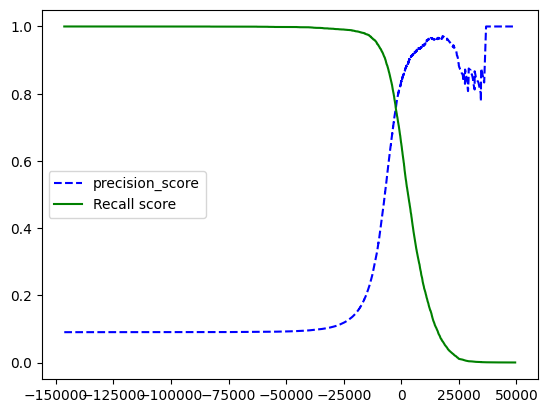

In [20]:
plot_precision_recall_vs_threshold(precisions,recalls,thresholds)
plt.legend(["precision_score","Recall score"])
plt.show()

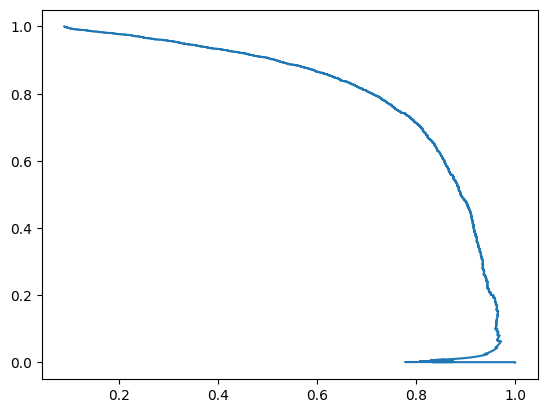

In [21]:
plt.plot(precisions,recalls)

In [22]:
threshold_90_precision = thresholds[np.argmax(precisions >= 0.90)]

In [23]:
y_train_pred_90 = (y_scores >= threshold_90_precision)

In [24]:
precision_score(y_train_5,y_train_pred_90)

0.9000345901072293

In [25]:
recall_score(y_train_5,y_train_pred_90)

0.4799852425751706

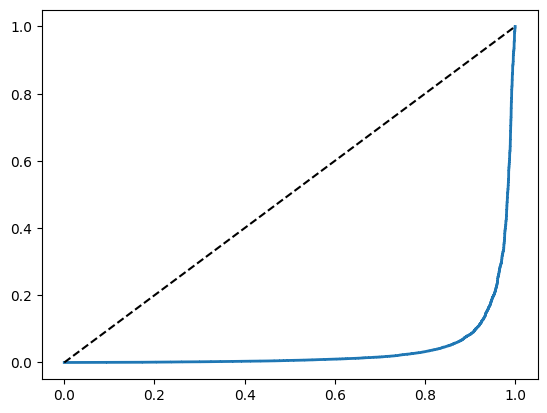

In [26]:
from sklearn.metrics import roc_curve
tpr, fpr, threshold = roc_curve(y_train_5,y_scores)
plt.plot(fpr, tpr, linewidth=2)
plt.plot([0, 1], [0, 1], 'k--')
plt.show()


In [27]:
from sklearn.metrics import roc_auc_score
roc_auc_score(y_train_5, y_scores)

0.9604938554008616

In [ ]:
# from sklearn.ensemble import RandomForestClassifier
# forest_clg = RandomForestClassifier(random_state= 42)
# y_probas_forest = cross_val_predict(forest_clg,X_train,y_train_5,cv=3,method="predict_proba")

In [ ]:
# y_scores_forest = y_probas_forest[:,1]
# fpr_forest, tpr_forest , threshold_forest = roc_curve(y_train_5,y_scores_forest)

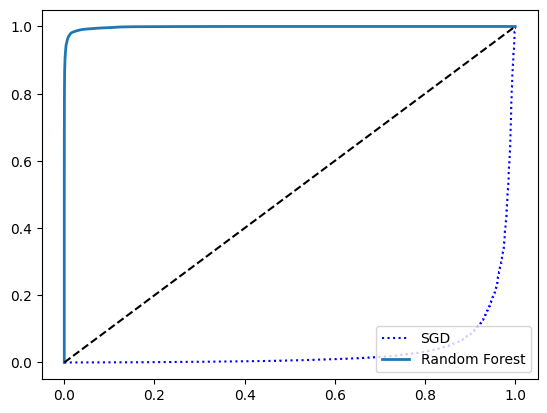

In [ ]:
# def plot_roc_curve(fpr, tpr, label=None):
#     plt.plot(fpr, tpr, linewidth=2, label=label)
#     plt.plot([0, 1], [0, 1], 'k--')

# plt.plot(fpr,tpr,"b:",label = "SGD")
# plot_roc_curve(fpr_forest,tpr_forest,"Random Forest")
# plt.legend(loc="lower right")
# plt.show()

In [ ]:
# y_forest_score = cross_val_predict(forest_clg,X_train,y_train_5,cv = 3)

In [ ]:
# print(precision_score(y_train_5,y_forest_score))
# print(recall_score(y_train_5,y_forest_score))

0.9905083315756169
0.8662608374838591


In [33]:
# from sklearn.svm import SVC
# svm_clf = SVC()
# svm_clf.fit(X_train,y_train)
# svm_clf.predict([some_digit])

In [34]:
# from sklearn.multiclass import OneVsRestClassifier
# ovr_clf = OneVsRestClassifier(SVC())
# ovr_clf.fit(X_train,y_train)
# ovr_clf.predict([some_digit])

In [35]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(X_train.astype(np.float64))

In [36]:
# from sklearn.model_selection import cross_val_predict
# y_train_pred = cross_val_predict(sgd_clf,x_train_scaled,y_train,cv=3)

In [37]:
# import joblib
# joblib.dump(y_train_pred,"y_train_pred.db")

In [38]:
import joblib
y_train_pred = joblib.load("y_train_pred.db")

In [39]:
from sklearn.metrics import confusion_matrix
conf_mx = confusion_matrix(y_train,y_train_pred)
conf_mx

array([[5573,    0,   23,    5,    8,   44,   36,    6,  227,    1],
       [   0, 6398,   37,   24,    4,   43,    4,    7,  214,   11],
       [  29,   25, 5220,   91,   73,   25,   68,   36,  380,   11],
       [  22,   17,  117, 5224,    2,  204,   27,   40,  405,   73],
       [  12,   14,   40,    9, 5181,   12,   34,   25,  351,  164],
       [  26,   15,   29,  165,   53, 4445,   74,   14,  541,   59],
       [  30,   15,   43,    3,   43,   96, 5551,    3,  133,    1],
       [  20,    9,   51,   29,   49,   12,    3, 5680,  200,  212],
       [  18,   64,   47,   89,    3,  124,   25,   10, 5426,   45],
       [  23,   18,   30,   65,  117,   37,    1,  179,  387, 5092]])

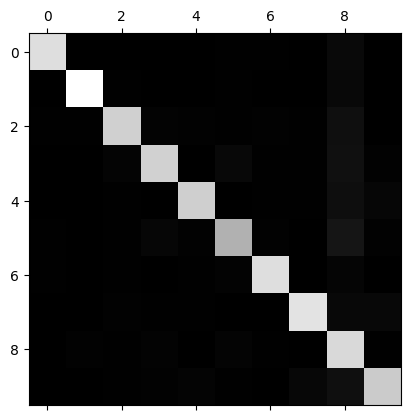

In [40]:
from matplotlib.pyplot import gray
plt.matshow(conf_mx,cmap = plt.cm.grey)

In [41]:
conf_mx

array([[5573,    0,   23,    5,    8,   44,   36,    6,  227,    1],
       [   0, 6398,   37,   24,    4,   43,    4,    7,  214,   11],
       [  29,   25, 5220,   91,   73,   25,   68,   36,  380,   11],
       [  22,   17,  117, 5224,    2,  204,   27,   40,  405,   73],
       [  12,   14,   40,    9, 5181,   12,   34,   25,  351,  164],
       [  26,   15,   29,  165,   53, 4445,   74,   14,  541,   59],
       [  30,   15,   43,    3,   43,   96, 5551,    3,  133,    1],
       [  20,    9,   51,   29,   49,   12,    3, 5680,  200,  212],
       [  18,   64,   47,   89,    3,  124,   25,   10, 5426,   45],
       [  23,   18,   30,   65,  117,   37,    1,  179,  387, 5092]])

In [44]:
row_sums = conf_mx.sum(axis = 1 , keepdims=True)
norm_conf_mx = conf_mx/row_sums

In [49]:
np.fill_diagonal(norm_conf_mx,0)

In [50]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

def plot_digits(instances, images_per_row=10, **options):
    size = 28
    images_per_row = min(len(instances), images_per_row)
    if images_per_row == 0:
        return
    n_rows = (len(instances) - 1) // images_per_row + 1
    
    # Append empty images to fill the end of the grid, if needed:
    n_empty = n_rows * images_per_row - len(instances)
    padded_instances = np.concatenate([instances, np.zeros((n_empty, size * size))], axis=0)
    
    # Reshape the array so it's organized as a grid containing 28x28 images:
    image_grid = padded_instances.reshape((n_rows, images_per_row, size, size))
    
    # Combine axes 0 and 2 (vertical image grid axis, and vertical image axis),
    # and axes 1 and 3 (horizontal axes). We first need to move the axes that we
    # want to combine next to each other, using transpose, and only then we
    # can reshape:
    big_image = image_grid.transpose(0, 2, 1, 3).reshape(n_rows * size,
                                                         images_per_row * size)
    # Now that we have a big image, we just need to show it:
    plt.imshow(big_image, cmap=mpl.cm.binary, **options)
    plt.axis("off")


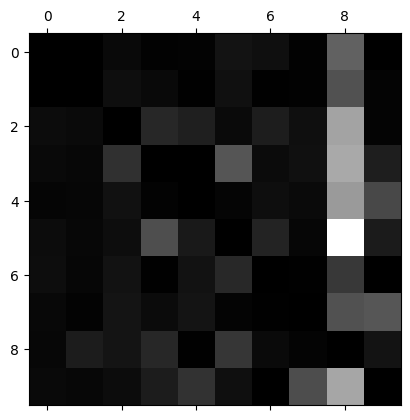

In [51]:
plt.matshow(norm_conf_mx,cmap = plt.cm.grey)
plt.show()

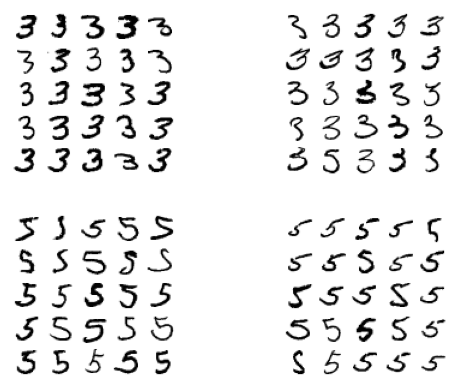

In [52]:
cl_a, cl_b = 3, 5
X_aa = X_train[(y_train == cl_a) & (y_train_pred == cl_a)]
X_ab = X_train[(y_train == cl_a) & (y_train_pred == cl_b)]
X_ba = X_train[(y_train == cl_b) & (y_train_pred == cl_a)]
X_bb = X_train[(y_train == cl_b) & (y_train_pred == cl_b)]
plt.subplot(221); plot_digits(X_aa[:25], images_per_row=5)
plt.subplot(222); plot_digits(X_ab[:25], images_per_row=5)
plt.subplot(223); plot_digits(X_ba[:25], images_per_row=5)
plt.subplot(224); plot_digits(X_bb[:25], images_per_row=5)
plt.show()